# Term Life Insurance Empirical Analysis

**ME315 Machine Learning in Practice - Problem Set Day 4, Question 3**

This notebook conducts the empirical analysis for the Term Life Insurance dataset. The purpose is not only to answer the problem-set question, but also to practise the empirical workflow needed for the final project: clear research design, careful data inspection, defensible feature choices, model comparison, and honest interpretation.


## Research Design

The main empirical question is:

> Which household and demographic characteristics are associated with the size of term life insurance coverage?

The main response variable is `FACE`, the amount paid out if the insured party dies. The data contain many households with `FACE = 0`, so there are really two related questions:

1. **Participation:** does the household have positive term life insurance coverage?
2. **Coverage size:** among households with positive coverage, how large is the coverage?

For the main analysis, I focus on **coverage size conditional on positive coverage**, using `logFACE = log(FACE)` as the response. This follows the case-study logic and is appropriate because `FACE` is highly skewed. I then add a shorter classification extension for whether `FACE > 0`, linking the analysis to Day 5.

The methods used connect directly to Days 1-5:

- Day 1: data inspection, train/test split, RMSE.
- Day 2: feature engineering and transformations.
- Day 3: flexibility, test performance, and overfitting.
- Day 4: Ridge and Lasso regularisation.
- Day 5: logistic regression and classification evaluation.

Important limitation: this is observational data, so I interpret results as **associations useful for prediction and description**, not as causal effects.


In [1]:
# Import core libraries for data handling, plots, modelling, and evaluation.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    log_loss,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import statsmodels.api as sm

# Suppress harmless numerical warnings from repeated regularised model fits.
# The notebook still checks final outputs and model diagnostics explicitly.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Make tables easier to read.
pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

# Define RMSE manually for compatibility across scikit-learn versions.
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


## 1. Load and Inspect the Data

The dataset contains 500 US households with positive income from the 2004 Survey of Consumer Finances. The case-study notebook originally refers to `TermLifeInsurance.csv`, but the actual file in this folder is `Term Life Insurance.csv`, so I load that file directly.


In [2]:
# Load the dataset. The CSV is stored in the same folder as this notebook for reproducibility.
data = pd.read_csv("Term Life Insurance.csv")

# Check the size and first rows.
print("Rows and columns:", data.shape)
data.head()


Rows and columns: (500, 18)


,GENDER,AGE,MARSTAT,EDUCATION,ETHNICITY,SMARSTAT,SGENDER,SAGE,SEDUCATION,NUMHH,INCOME,TOTINCOME,CHARITY,FACE,FACECVLIFEPOLICIES,CASHCVLIFEPOLICIES,BORROWCVLIFEPOL,NETVALUE
0,1,30,1,16,3,2,2,27,16,3,43000,43000,0,20000,0,0,0,0
1,1,50,1,9,3,1,2,47,8,3,12000,0,0,130000,0,0,0,0
2,1,39,1,16,1,2,2,38,16,5,120000,90000,500,1500000,0,0,0,0
3,1,43,1,17,1,1,2,35,14,4,40000,40000,0,50000,75000,0,5,0
4,1,61,1,15,1,2,2,59,12,2,25000,1020000,500,0,7000000,300000,5,0


In [3]:
# Check variable types and missing values.
# There are no missing values in this dataset, so no imputation is needed.
summary_check = pd.DataFrame({
    "dtype": data.dtypes,
    "missing_values": data.isna().sum(),
    "unique_values": data.nunique()
})
summary_check


,dtype,missing_values,unique_values
GENDER,int64,0,2
AGE,int64,0,63
MARSTAT,int64,0,3
EDUCATION,int64,0,16
ETHNICITY,int64,0,4
SMARSTAT,int64,0,4
SGENDER,int64,0,3
SAGE,int64,0,58
SEDUCATION,int64,0,16
NUMHH,int64,0,9


### Variable Notes

The main variables used in this analysis are:

- `FACE`: payout amount if the insured party dies. This is the main outcome.
- `INCOME`: annual family income.
- `AGE`: age of respondent.
- `GENDER`: gender code of respondent.
- `MARSTAT`: marital status code (`0` otherwise, `1` married, `2` living with partner).
- `EDUCATION`: years of education.
- `NUMHH`: number of household members.

I deliberately do **not** use variables such as `FACECVLIFEPOLICIES`, `CASHCVLIFEPOLICIES`, and `BORROWCVLIFEPOL` in the main predictor set. These are also life-insurance-policy variables and may be too mechanically related to the outcome. Excluding them makes the analysis cleaner and more useful for understanding household characteristics.


In [4]:
# Summary statistics for all variables.
data.describe().T


,count,mean,std,min,25%,50%,75%,max
GENDER,500.0,0.826,3.795e-01,0.0,1.0,1.0,1.0,1.000e+00
AGE,500.0,47.164,1.385e+01,20.0,37.0,47.0,58.0,8.500e+01
MARSTAT,500.0,0.790,5.390e-01,0.0,0.0,1.0,1.0,2.000e+00
EDUCATION,500.0,14.062,2.942e+00,2.0,12.0,14.0,16.0,1.700e+01
ETHNICITY,500.0,1.600,1.380e+00,1.0,1.0,1.0,2.0,7.000e+00
SMARSTAT,500.0,1.198,8.697e-01,0.0,0.0,1.0,2.0,3.000e+00
SGENDER,500.0,1.446,8.903e-01,0.0,0.0,2.0,2.0,2.000e+00
SAGE,500.0,33.398,2.321e+01,0.0,0.0,39.0,51.0,7.800e+01
SEDUCATION,500.0,10.016,6.682e+00,0.0,0.0,12.0,16.0,1.700e+01
NUMHH,500.0,2.870,1.495e+00,1.0,2.0,2.0,4.0,9.000e+00


## 2. Outcome Exploration

Before modelling, I inspect the response variable carefully. This is important because modelling raw insurance amounts can be misleading if the distribution is heavily skewed or has many zeros.


In [5]:
# Create useful outcome indicators and transformations.
data = data.copy()
data["has_FACE"] = (data["FACE"] > 0).astype(int)
data["logINCOME"] = np.log(data["INCOME"])
data["logTOTINCOME_1p"] = np.log1p(data["TOTINCOME"])
data["logCHARITY_1p"] = np.log1p(data["CHARITY"])

# logFACE is only defined for positive FACE.
# I assign it only on positive rows to avoid taking log(0).
data["logFACE"] = np.nan
positive_face_mask = data["FACE"] > 0
data.loc[positive_face_mask, "logFACE"] = np.log(data.loc[positive_face_mask, "FACE"])

print("Households:", len(data))
print("Households with FACE = 0:", (data["FACE"] == 0).sum())
print("Households with FACE > 0:", (data["FACE"] > 0).sum())
print("Positive coverage rate:", round(data["has_FACE"].mean(), 3))


Households: 500
Households with FACE = 0: 225
Households with FACE > 0: 275
Positive coverage rate: 0.55


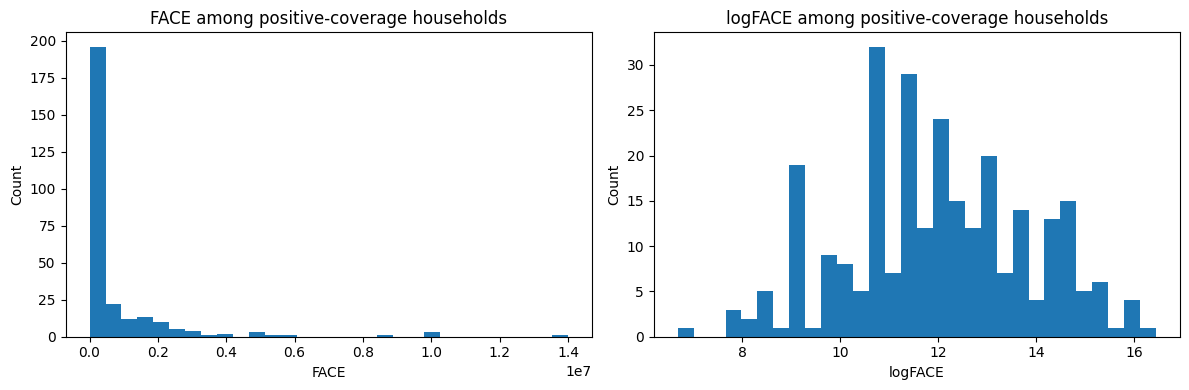

In [6]:
# Compare raw FACE with logFACE among positive-coverage households.
positive = data[data["FACE"] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(positive["FACE"], bins=30)
axes[0].set_title("FACE among positive-coverage households")
axes[0].set_xlabel("FACE")
axes[0].set_ylabel("Count")

axes[1].hist(positive["logFACE"], bins=30)
axes[1].set_title("logFACE among positive-coverage households")
axes[1].set_xlabel("logFACE")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


### Note

`FACE` is strongly right-skewed: a small number of households have extremely large policy values. The log transformation makes the outcome more suitable for linear regression because it compresses the extreme upper tail and makes relationships easier to model.


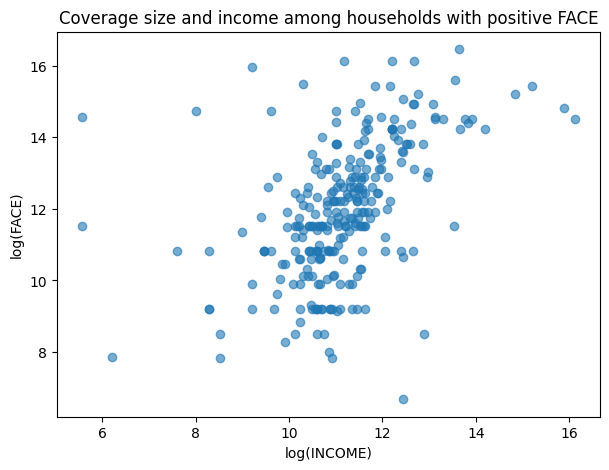

,FACE,INCOME,logFACE,logINCOME,AGE,EDUCATION,NUMHH
FACE,1.000,0.217,0.656,0.323,0.095,0.244,0.107
INCOME,0.217,1.000,0.251,0.518,0.005,0.163,0.142
logFACE,0.656,0.251,1.000,0.482,-0.046,0.383,0.288
logINCOME,0.323,0.518,0.482,1.000,0.045,0.343,0.179
AGE,0.095,0.005,-0.046,0.045,1.000,0.092,-0.318
EDUCATION,0.244,0.163,0.383,0.343,0.092,1.000,-0.064
NUMHH,0.107,0.142,0.288,0.179,-0.318,-0.064,1.000


In [7]:
# Explore the key income relationship after log transformation.
plt.figure(figsize=(7, 5))
plt.scatter(positive["logINCOME"], positive["logFACE"], alpha=0.6)
plt.xlabel("log(INCOME)")
plt.ylabel("log(FACE)")
plt.title("Coverage size and income among households with positive FACE")
plt.show()

positive[["FACE", "INCOME", "logFACE", "logINCOME", "AGE", "EDUCATION", "NUMHH"]].corr()


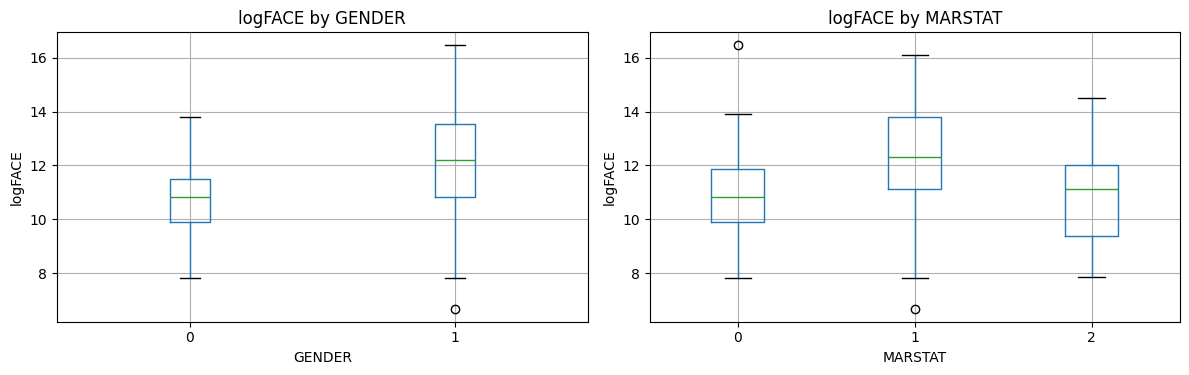

In [8]:
# Boxplots for categorical predictors.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

positive.boxplot(column="logFACE", by="GENDER", ax=axes[0])
axes[0].set_title("logFACE by GENDER")
axes[0].set_xlabel("GENDER")
axes[0].set_ylabel("logFACE")

positive.boxplot(column="logFACE", by="MARSTAT", ax=axes[1])
axes[1].set_title("logFACE by MARSTAT")
axes[1].set_xlabel("MARSTAT")
axes[1].set_ylabel("logFACE")

plt.suptitle("")
plt.tight_layout()
plt.show()


## 3. Feature Engineering

I use a compact, interpretable feature set:

- `logINCOME`: transformed income.
- `AGE_c` and `AGE_c_sq`: age centred at 50 and its square. Age may have a nonlinear relationship with insurance needs, and centring reduces unnecessary multicollinearity.
- `EDUCATION`: human capital / socioeconomic proxy.
- `NUMHH`: household size, a proxy for household responsibilities.
- `GENDER`: demographic indicator.
- `MARSTAT` dummies: marital status is categorical, not continuous.

I also create an extended feature set with `logTOTINCOME_1p`, `logCHARITY_1p`, and ethnicity dummies. This lets Ridge/Lasso decide whether extra information improves prediction, while the core model remains easier to explain.


In [9]:
def make_features(df, extended=False):
    """Create model features from the raw insurance dataframe."""
    X = pd.DataFrame(index=df.index)

    # Core predictors.
    X["logINCOME"] = np.log(df["INCOME"])
    # Centre age at 50 before squaring.
    # This keeps the nonlinear age term interpretable and numerically stable.
    X["AGE_c"] = df["AGE"] - 50
    X["AGE_c_sq"] = X["AGE_c"] ** 2
    X["EDUCATION"] = df["EDUCATION"]
    X["NUMHH"] = df["NUMHH"]
    X["GENDER"] = df["GENDER"]

    # Dummy-code marital status, with MARSTAT = 0 as the baseline.
    marstat_dummies = pd.get_dummies(df["MARSTAT"], prefix="MARSTAT", drop_first=True, dtype=int)
    X = pd.concat([X, marstat_dummies], axis=1)

    if extended:
        # Extra predictors that may help prediction but make interpretation less compact.
        X["logTOTINCOME_1p"] = np.log1p(df["TOTINCOME"])
        X["logCHARITY_1p"] = np.log1p(df["CHARITY"])

        ethnicity_dummies = pd.get_dummies(df["ETHNICITY"], prefix="ETHNICITY", drop_first=True, dtype=int)
        X = pd.concat([X, ethnicity_dummies], axis=1)

    return X

X_core = make_features(positive, extended=False)
X_extended = make_features(positive, extended=True)
y_amount = positive["logFACE"]

X_core.head()


,logINCOME,AGE_c,AGE_c_sq,EDUCATION,NUMHH,GENDER,MARSTAT_1,MARSTAT_2
0,10.669,-20,400,16,3,1,1,0
1,9.393,0,0,9,3,1,1,0
2,11.695,-11,121,16,5,1,1,0
3,10.597,-7,49,17,4,1,1,0
5,10.240,-16,256,11,4,1,0,1


## 4. Main Regression Analysis: Predicting `logFACE`

The main analysis uses only households with positive coverage. I split the data into training and test sets so model comparison is based on generalisation, not just in-sample fit.


In [10]:
# Train-test split for the coverage-size regression.
X_train_core, X_test_core, y_train, y_test = train_test_split(
    X_core, y_amount, test_size=0.25, random_state=123
)

X_train_ext, X_test_ext, _, _ = train_test_split(
    X_extended, y_amount, test_size=0.25, random_state=123
)

print("Training observations:", X_train_core.shape[0])
print("Test observations:", X_test_core.shape[0])


Training observations: 206
Test observations: 69


In [11]:
# Baseline model: logFACE predicted only by logINCOME.
X_train_income = X_train_core[["logINCOME"]]
X_test_income = X_test_core[["logINCOME"]]

baseline = LinearRegression()
baseline.fit(X_train_income, y_train)

baseline_train_pred = baseline.predict(X_train_income)
baseline_test_pred = baseline.predict(X_test_income)

print("Baseline train RMSE:", round(rmse(y_train, baseline_train_pred), 3))
print("Baseline test RMSE:", round(rmse(y_test, baseline_test_pred), 3))
print("Baseline test R-squared:", round(r2_score(y_test, baseline_test_pred), 3))


Baseline train RMSE: 1.658
Baseline test RMSE: 1.587
Baseline test R-squared: 0.194


In [12]:
# Core OLS model using interpretable household characteristics.
ols_core = LinearRegression()
ols_core.fit(X_train_core, y_train)

ols_core_train_pred = ols_core.predict(X_train_core)
ols_core_test_pred = ols_core.predict(X_test_core)

print("Core OLS train RMSE:", round(rmse(y_train, ols_core_train_pred), 3))
print("Core OLS test RMSE:", round(rmse(y_test, ols_core_test_pred), 3))
print("Core OLS test R-squared:", round(r2_score(y_test, ols_core_test_pred), 3))


Core OLS train RMSE: 1.489
Core OLS test RMSE: 1.448
Core OLS test R-squared: 0.329


In [13]:
# Statsmodels OLS is useful for coefficient tables and p-values.
# This is fit on the training data to stay consistent with the prediction workflow.
X_train_sm = sm.add_constant(X_train_core).astype(float)
ols_sm = sm.OLS(y_train, X_train_sm).fit()

ols_sm.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                logFACE   R-squared:                       0.378
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     14.94
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           5.01e-17
Time:                        00:16:19   Log-Likelihood:                -374.37
No. Observations:                 206   AIC:                             766.7
Df Residuals:                     197   BIC:                             796.7
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9033      1.050      2.765      0.006       0.833       4.974
logINCOME      0.4064      0.098      4.128      0.000       0.212       0.601
AGE_c         -0.0062      0.010     -0.641      0.522      -0.025       0.013
AGE_c_sq      -0.0007      0.001     -1.372      0.172      -0.002       0.000
EDUCATION      0.2212      0.044      5.032      0.000       0.135       0.308
NUMHH          0.2200      0.094      2.329      0.021       0.034       0.406
GENDER         0.5166      0.429      1.204      0.230      -0.330       1.363
MARSTAT_1      0.3949      0.399      0.991      0.323      -0.391       1.181
MARSTAT_2     -0.5715      0.633     -0.903      0.368      -1.819       0.676
==============================================================================
Omnibus:                        9.824   Durbin-Watson:                   2.060
Prob(Omnibus):                  0.007   Jarque-Bera (JB):               15.644
Skew:                          -0.253   Prob(JB):                     0.000401
Kurtosis:                       4.252   Cond. No.                     2.56e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.56e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Full-Sample OLS for Report Interpretation

The train/test OLS table above is useful for keeping the prediction workflow consistent. For the written report, however, coefficient interpretation is clearer if the main interpretable OLS model is also estimated on the full positive-coverage sample.

I use heteroskedasticity-robust (`HC3`) standard errors because insurance amounts are variable and the residual variance is unlikely to be perfectly constant.


In [14]:
# Full-sample interpretable OLS model with robust standard errors.
# This table is intended for coefficient interpretation in the report.
X_full_sm = sm.add_constant(X_core).astype(float)
y_full = y_amount

ols_full_robust = sm.OLS(y_full, X_full_sm).fit(cov_type="HC3")
ols_full_robust.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                logFACE   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.357
Method:                 Least Squares   F-statistic:                     30.98
Date:                Mon, 29 Jun 2026   Prob (F-statistic):           4.35e-34
Time:                        00:16:19   Log-Likelihood:                -497.18
No. Observations:                 275   AIC:                             1012.
Df Residuals:                     266   BIC:                             1045.
Df Model:                           8                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0640      1.049      2.920      0.003       1.008       5.121
logINCOME      0.4116      0.121      3.389      0.001       0.174       0.650
AGE_c         -0.0095      0.008     -1.146      0.252      -0.026       0.007
AGE_c_sq      -0.0009      0.000     -1.919      0.055      -0.002    1.86e-05
EDUCATION      0.2125      0.044      4.848      0.000       0.127       0.298
NUMHH          0.2058      0.071      2.893      0.004       0.066       0.345
GENDER         0.7005      0.326      2.147      0.032       0.061       1.340
MARSTAT_1      0.2277      0.331      0.688      0.491      -0.421       0.876
MARSTAT_2     -0.6081      0.624     -0.974      0.330      -1.832       0.615
==============================================================================
Omnibus:                       11.991   Durbin-Watson:                   1.849
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               20.942
Skew:                          -0.227   Prob(JB):                     2.84e-05
Kurtosis:                       4.273   Cond. No.                     2.50e+03
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
[2] The condition number is large, 2.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Interpretation Note

The coefficient on `logINCOME` is especially important. In a log-log model, it can be read approximately as an elasticity: a 1% increase in income is associated with about a `beta`% increase in face value, conditional on the other variables. This is still an association, not a causal estimate.


In [15]:
# Ridge and Lasso on the extended feature set.
# Standardisation is needed because Ridge and Lasso penalise coefficient size.
ridge = make_pipeline(
    StandardScaler(),
    RidgeCV(alphas=np.logspace(-4, 4, 100))
)

lasso = make_pipeline(
    StandardScaler(),
    LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=100000, random_state=123)
)

ridge.fit(X_train_ext, y_train)
lasso.fit(X_train_ext, y_train)

ridge_train_pred = ridge.predict(X_train_ext)
ridge_test_pred = ridge.predict(X_test_ext)

lasso_train_pred = lasso.predict(X_train_ext)
lasso_test_pred = lasso.predict(X_test_ext)

print("Best Ridge alpha:", ridge.named_steps["ridgecv"].alpha_)
print("Best Lasso alpha:", lasso.named_steps["lassocv"].alpha_)


Best Ridge alpha: 45.34878508128591
Best Lasso alpha: 0.06734150657750822


In [16]:
# Compare regression models using train and test performance.
regression_results = pd.DataFrame({
    "model": ["Baseline: logINCOME", "Core OLS", "Extended Ridge", "Extended Lasso"],
    "train_RMSE": [
        rmse(y_train, baseline_train_pred),
        rmse(y_train, ols_core_train_pred),
        rmse(y_train, ridge_train_pred),
        rmse(y_train, lasso_train_pred)
    ],
    "test_RMSE": [
        rmse(y_test, baseline_test_pred),
        rmse(y_test, ols_core_test_pred),
        rmse(y_test, ridge_test_pred),
        rmse(y_test, lasso_test_pred)
    ],
    "test_MAE": [
        mean_absolute_error(y_test, baseline_test_pred),
        mean_absolute_error(y_test, ols_core_test_pred),
        mean_absolute_error(y_test, ridge_test_pred),
        mean_absolute_error(y_test, lasso_test_pred)
    ],
    "test_R2": [
        r2_score(y_test, baseline_test_pred),
        r2_score(y_test, ols_core_test_pred),
        r2_score(y_test, ridge_test_pred),
        r2_score(y_test, lasso_test_pred)
    ]
})

regression_results.round(3).sort_values("test_RMSE")


,model,train_RMSE,test_RMSE,test_MAE,test_R2
2,Extended Ridge,1.405,1.438,1.092,0.338
1,Core OLS,1.489,1.448,1.078,0.329
3,Extended Lasso,1.413,1.449,1.121,0.329
0,Baseline: logINCOME,1.658,1.587,1.202,0.194


### Robustness Check: Repeated Train/Test Splits

A single train/test split can be noisy, especially with only 275 positive-coverage observations. To check whether the model ranking is stable, I repeat the train/test evaluation over several random splits.

This is not a replacement for careful interpretation, but it is a useful robustness check before writing the report.


In [17]:
# Repeated train/test comparison for the regression models.
# This checks whether the conclusion depends too much on one random split.
seeds = list(range(100, 130))
robustness_rows = []

for seed in seeds:
    X_train_core_s, X_test_core_s, y_train_s, y_test_s = train_test_split(
        X_core, y_amount, test_size=0.25, random_state=seed
    )
    X_train_ext_s, X_test_ext_s, _, _ = train_test_split(
        X_extended, y_amount, test_size=0.25, random_state=seed
    )

    # Baseline income-only model.
    baseline_s = LinearRegression()
    baseline_s.fit(X_train_core_s[["logINCOME"]], y_train_s)
    pred_baseline_s = baseline_s.predict(X_test_core_s[["logINCOME"]])

    # Core OLS.
    core_s = LinearRegression()
    core_s.fit(X_train_core_s, y_train_s)
    pred_core_s = core_s.predict(X_test_core_s)

    # Extended Ridge.
    ridge_s = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-4, 4, 100))
    )
    ridge_s.fit(X_train_ext_s, y_train_s)
    pred_ridge_s = ridge_s.predict(X_test_ext_s)

    # Extended Lasso.
    lasso_s = make_pipeline(
        StandardScaler(),
        LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=100000, random_state=seed)
    )
    lasso_s.fit(X_train_ext_s, y_train_s)
    pred_lasso_s = lasso_s.predict(X_test_ext_s)

    predictions = {
        "Baseline: logINCOME": pred_baseline_s,
        "Core OLS": pred_core_s,
        "Extended Ridge": pred_ridge_s,
        "Extended Lasso": pred_lasso_s
    }

    for model_name, prediction in predictions.items():
        robustness_rows.append({
            "seed": seed,
            "model": model_name,
            "test_RMSE": rmse(y_test_s, prediction),
            "test_R2": r2_score(y_test_s, prediction)
        })

robustness_results = pd.DataFrame(robustness_rows)

robustness_summary = (
    robustness_results
    .groupby("model")
    .agg(
        mean_test_RMSE=("test_RMSE", "mean"),
        sd_test_RMSE=("test_RMSE", "std"),
        mean_test_R2=("test_R2", "mean")
    )
    .sort_values("mean_test_RMSE")
)

robustness_summary.round(3)


,mean_test_RMSE,sd_test_RMSE,mean_test_R2
model,,,
Extended Ridge,1.488,0.151,0.338
Extended Lasso,1.497,0.159,0.329
Core OLS,1.542,0.157,0.287
Baseline: logINCOME,1.662,0.180,0.168


In [18]:
# Count how often each model gives the lowest test RMSE across repeated splits.
best_by_split = (
    robustness_results
    .sort_values(["seed", "test_RMSE"])
    .groupby("seed")
    .head(1)
)

best_by_split["model"].value_counts()


model
Extended Ridge         18
Extended Lasso          8
Core OLS                3
Baseline: logINCOME     1
Name: count, dtype: int64

### Robustness Interpretation

The repeated-split results should be used to avoid overstating one split. If Ridge has the lowest average RMSE but Core OLS is close, the report should present Ridge as modestly better for prediction while still using Core OLS for interpretation.


In [19]:
# Inspect which variables Lasso keeps.
lasso_model = lasso.named_steps["lassocv"]
lasso_coefs = pd.DataFrame({
    "feature": X_extended.columns,
    "standardised_lasso_coefficient": lasso_model.coef_,
    "abs_coefficient": np.abs(lasso_model.coef_)
}).sort_values("abs_coefficient", ascending=False)

print("Number of non-zero Lasso coefficients:", (lasso_coefs["abs_coefficient"] > 1e-8).sum())
lasso_coefs


Number of non-zero Lasso coefficients: 8


,feature,standardised_lasso_coefficient,abs_coefficient
9,logCHARITY_1p,0.450,0.450
8,logTOTINCOME_1p,0.396,0.396
3,EDUCATION,0.308,0.308
0,logINCOME,0.295,0.295
4,NUMHH,0.198,0.198
1,AGE_c,-0.190,0.190
2,AGE_c_sq,-0.138,0.138
12,ETHNICITY_7,-0.008,0.008
5,GENDER,0.000,0.000
6,MARSTAT_1,0.000,0.000


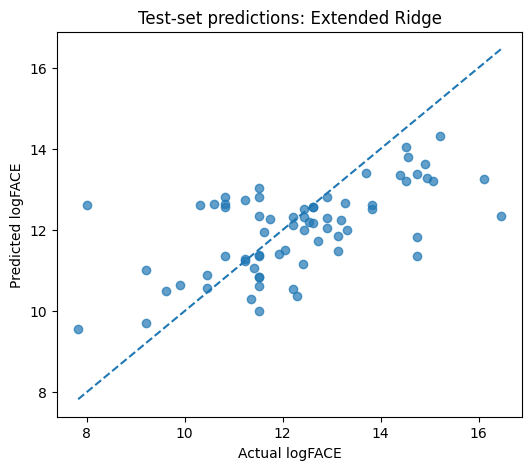

In [20]:
# Plot predicted versus actual logFACE for the best test-RMSE model.
best_model_name = regression_results.sort_values("test_RMSE").iloc[0]["model"]

if best_model_name == "Baseline: logINCOME":
    best_predictions = baseline_test_pred
elif best_model_name == "Core OLS":
    best_predictions = ols_core_test_pred
elif best_model_name == "Extended Ridge":
    best_predictions = ridge_test_pred
else:
    best_predictions = lasso_test_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_test, best_predictions, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.xlabel("Actual logFACE")
plt.ylabel("Predicted logFACE")
plt.title("Test-set predictions: " + best_model_name)
plt.show()


### Regression Findings to Carry Into the Report

The report should emphasise three points:

1. `FACE` and `INCOME` are highly skewed, so log transformation is a necessary modelling choice.
2. Income is a robust predictor of coverage size among households with positive coverage.
3. More flexible models should be judged by test RMSE, not only by in-sample fit. Ridge and Lasso are useful checks against overfitting when extra predictors are added.


## 5. Classification Extension: Predicting Any Positive Coverage

Because many households have `FACE = 0`, a complete empirical analysis should acknowledge the participation margin. I therefore fit a short logistic-regression extension predicting whether a household has any positive coverage.

This is not the main analysis, but it is valuable because it uses Day 5 methods and shows that the zero values are substantively important rather than just a nuisance.


In [21]:
# Classification target: whether FACE is positive.
X_class = make_features(data, extended=True)
y_class = data["has_FACE"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_class, y_class, test_size=0.25, random_state=123, stratify=y_class
)

print("Training positive rate:", round(yc_train.mean(), 3))
print("Test positive rate:", round(yc_test.mean(), 3))


Training positive rate: 0.549
Test positive rate: 0.552


In [22]:
# Fit ordinary, Ridge, and Lasso logistic regression models.
# C is the inverse of regularisation strength.
logistic_models = {
    "Logistic, very weak penalty": make_pipeline(
        StandardScaler(),
        LogisticRegression(C=100, solver="lbfgs", max_iter=5000)
    ),
    "Ridge logistic": make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=5000)
    ),
    "Lasso logistic": make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l1", C=0.1, solver="liblinear", max_iter=5000)
    )
}

classification_rows = []

for name, model in logistic_models.items():
    model.fit(Xc_train, yc_train)
    prob = model.predict_proba(Xc_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    classification_rows.append({
        "model": name,
        "accuracy": accuracy_score(yc_test, pred),
        "precision": precision_score(yc_test, pred, zero_division=0),
        "recall": recall_score(yc_test, pred, zero_division=0),
        "F1": f1_score(yc_test, pred, zero_division=0),
        "AUC": roc_auc_score(yc_test, prob),
        "log_loss": log_loss(yc_test, prob)
    })

classification_results = pd.DataFrame(classification_rows)
classification_results.round(3).sort_values("log_loss")


,model,accuracy,precision,recall,F1,AUC,log_loss
2,Lasso logistic,0.664,0.680,0.739,0.708,0.707,0.636
1,Ridge logistic,0.608,0.622,0.739,0.675,0.658,0.645
0,"Logistic, very weak penalty",0.600,0.614,0.739,0.671,0.656,0.646


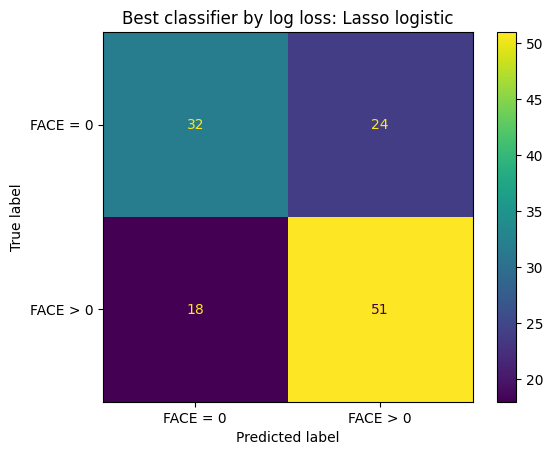

In [23]:
# Confusion matrix for the best classifier by log loss.
best_classifier_name = classification_results.sort_values("log_loss").iloc[0]["model"]
best_classifier = logistic_models[best_classifier_name]

best_prob = best_classifier.predict_proba(Xc_test)[:, 1]
best_pred = (best_prob >= 0.5).astype(int)

cm = confusion_matrix(yc_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["FACE = 0", "FACE > 0"])
disp.plot(values_format="d")
plt.title("Best classifier by log loss: " + best_classifier_name)
plt.show()


### Classification Findings to Carry Into the Report

The classification extension addresses a different question from the main regression: whether a household has any positive coverage. This is useful because `FACE = 0` is common in the data. However, the 3-page report should keep the regression on `logFACE` as the main analysis and use the classification section as a concise extension or robustness check.


## 6. Overall Conclusion

This notebook supports a concise empirical report with the following argument:

- The Term Life Insurance data require careful preprocessing because coverage amounts are highly skewed and many households have zero coverage.
- For households with positive coverage, modelling `logFACE` is more appropriate than modelling raw `FACE`.
- Income is the most important and stable predictor of coverage size in the interpretable models.
- Demographic and household variables add context, but their effects are less stable and should not be interpreted causally.
- Ridge and Lasso provide useful regularised comparisons when the feature set is expanded.
- A classification extension confirms that the participation decision (`FACE > 0`) is a distinct empirical question.

For the 3-page write-up, the strongest structure is:

1. Research question and data.
2. Empirical strategy and model comparison.
3. Results, limitations, and conclusion.


## Appendix: Reproducibility Notes

The reproducible empirical materials for this problem set are:

- `Term_Life_Insurance_Q3_Empirical_Analysis.ipynb`
- `Term Life Insurance.csv`
- `ProblemSetDay04.pdf`

For clarity and reproducibility, the notebook and dataset should be kept in the same folder. If the notebook is uploaded to GitHub, the dataset should be uploaded with it unless course rules or data permissions say otherwise. The report appendix can mention the repository location, package requirements, and that all tables/figures in the report are generated from this notebook.

This appendix material is not part of the 3-page empirical report body, but it supports transparent and reproducible empirical work.
